In [4]:
# --- import libraries ---
import pandas as pd
import numpy as np
import os
import shutil
from lifelines import CoxPHFitter
from lifelines.exceptions import ConvergenceError
from sklearn.preprocessing import StandardScaler
from lifelines import WeibullAFTFitter
from typing import Tuple, Optional
import matplotlib.pyplot as plt
import seaborn as sns
import sys

sys.path.append('../utilities')
from preprocess import preprocess

PARTICIPANT_DATA_PATH = '../participant_data/'

In [5]:
## -- list of features elected by the aft model -- ##
Borrow_Deposit = ['amount', 'amountUSD', 'cosDayOfMonth', 'cosDayOfYear', 'dayOfMonth', 'dayOfYear', 'logAmount', 'logAmountUSD', 'marketBorrowAvgAmount', 'marketBorrowAvgAmountUSD', 'marketBorrowCount', 'marketBorrowSum', 'marketBorrowSumUSD', 'marketDepositAvgAmount', 'marketDepositAvgAmountUSD', 'marketDepositCount', 'marketDepositSum', 'marketDepositSumUSD', 'marketLiquidationAvgAmount', 'marketLiquidationAvgAmountUSD', 'marketLiquidationCount', 'marketLiquidationSum', 'marketLiquidationSumUSD', 'marketRepayAvgAmountUSD', 'marketRepayCount', 'marketRepaySum', 'marketRepaySumUSD', 'marketWithdrawAvgAmount', 'marketWithdrawAvgAmountUSD', 'marketWithdrawCount', 'marketWithdrawSum', 'marketWithdrawSumUSD', 'priceInUSD', 'quarter', 'sinDayOfQuarter', 'sinDayOfYear', 'sinQuarter', 'sinTimeOfDay', 'timeOfDay', 'userActiveDaysMonthly', 'userActiveDaysWeekly', 'userActiveDaysYearly', 'userBorrowAvgAmount', 'userBorrowAvgAmountUSD', 'userBorrowCount', 'userBorrowSum', 'userBorrowSumUSD', 'userDepositCount', 'userDepositSum', 'userDepositSumUSD', 'userLiquidationAvgAmount', 'userLiquidationAvgAmountUSD', 'userLiquidationCount', 'userLiquidationSum', 'userLiquidationSumUSD', 'userRepayAvgAmount', 'userRepayAvgAmountUSD', 'userRepayCount', 'userRepaySum', 'userRepaySumUSD', 'userSecondsSinceFirstTransaction', 'userSecondsSincePreviousTransaction', 'userWithdrawAvgAmount', 'userWithdrawAvgAmountUSD', 'userWithdrawCount', 'timeDiff', 'status']
Borrow_Repay = ['amount', 'amountUSD', 'cosDayOfQuarter', 'cosDayOfYear', 'cosQuarter', 'dayOfQuarter', 'dayOfYear', 'logAmount', 'logAmountUSD', 'marketBorrowAvgAmount', 'marketBorrowAvgAmountUSD', 'marketBorrowCount', 'marketBorrowSum', 'marketBorrowSumUSD', 'marketDepositAvgAmount', 'marketDepositAvgAmountUSD', 'marketDepositCount', 'marketLiquidationAvgAmount', 'marketLiquidationAvgAmountUSD', 'marketLiquidationCount', 'marketLiquidationSum', 'marketLiquidationSumUSD', 'marketRepayAvgAmountUSD', 'marketRepayCount', 'marketRepaySum', 'marketRepaySumUSD', 'marketWithdrawAvgAmount', 'marketWithdrawAvgAmountUSD', 'priceInUSD', 'quarter', 'sinDayOfYear', 'sinQuarter', 'sinTimeOfDay', 'timeOfDay', 'userActiveDaysMonthly', 'userActiveDaysWeekly', 'userActiveDaysYearly', 'userBorrowAvgAmount', 'userBorrowAvgAmountUSD', 'userBorrowCount', 'userBorrowSum', 'userBorrowSumUSD', 'userDepositAvgAmount', 'userDepositAvgAmountUSD', 'userDepositCount', 'userDepositSum', 'userLiquidationAvgAmountUSD', 'userLiquidationCount', 'userLiquidationSum', 'userLiquidationSumUSD', 'userRepayAvgAmount', 'userRepayAvgAmountUSD', 'userRepayCount', 'userRepaySum', 'userRepaySumUSD', 'userSecondsSinceFirstTransaction', 'userSecondsSincePreviousTransaction', 'userWithdrawAvgAmount', 'userWithdrawAvgAmountUSD', 'userWithdrawCount', 'userWithdrawSum', 'userWithdrawSumUSD', 'timeDiff', 'status']
Borrow_Withdraw = ['amount', 'amountUSD', 'cosDayOfQuarter', 'cosDayOfYear', 'cosQuarter', 'dayOfYear', 'logAmount', 'logAmountUSD', 'marketBorrowAvgAmountUSD', 'marketBorrowCount', 'marketBorrowSumUSD', 'marketDepositAvgAmount', 'marketDepositAvgAmountUSD', 'marketDepositCount', 'marketDepositSum', 'marketDepositSumUSD', 'marketLiquidationAvgAmount', 'marketLiquidationAvgAmountUSD', 'marketLiquidationCount', 'marketLiquidationSum', 'marketLiquidationSumUSD', 'marketRepayAvgAmount', 'marketRepayCount', 'marketRepaySumUSD', 'marketWithdrawAvgAmountUSD', 'marketWithdrawCount', 'marketWithdrawSum', 'marketWithdrawSumUSD', 'priceInUSD', 'quarter', 'sinDayOfQuarter', 'sinDayOfYear', 'sinTimeOfDay', 'timeOfDay', 'userActiveDaysMonthly', 'userActiveDaysWeekly', 'userActiveDaysYearly', 'userBorrowAvgAmount', 'userBorrowAvgAmountUSD', 'userBorrowCount', 'userBorrowSum', 'userBorrowSumUSD', 'userDepositAvgAmount', 'userDepositAvgAmountUSD', 'userDepositCount', 'userDepositSum', 'userDepositSumUSD', 'userLiquidationAvgAmount', 'userLiquidationCount', 'userLiquidationSum', 'userLiquidationSumUSD', 'userRepayAvgAmount', 'userRepayCount', 'userRepaySum', 'userRepaySumUSD', 'userSecondsSinceFirstTransaction', 'userSecondsSincePreviousTransaction', 'userWithdrawAvgAmount', 'userWithdrawAvgAmountUSD', 'userWithdrawCount', 'userWithdrawSum', 'userWithdrawSumUSD', 'timeDiff', 'status']
Borrow_Liquidated = ['amount', 'amountUSD', 'dayOfYear', 'logAmountUSD', 'marketBorrowCount', 'marketDepositAvgAmount', 'marketDepositAvgAmountUSD', 'marketDepositCount', 'marketDepositSumUSD', 'marketWithdrawSumUSD', 'priceInUSD', 'quarter', 'sinDayOfMonth', 'sinDayOfYear', 'sinQuarter', 'userActiveDaysMonthly', 'userActiveDaysWeekly', 'userActiveDaysYearly', 'userBorrowAvgAmount', 'userBorrowAvgAmountUSD', 'userBorrowCount', 'userBorrowSum', 'userBorrowSumUSD', 'userDepositAvgAmount', 'userDepositAvgAmountUSD', 'userDepositCount', 'userLiquidationAvgAmount', 'userLiquidationAvgAmountUSD', 'userLiquidationCount', 'userLiquidationSum', 'userRepayAvgAmount', 'userRepayAvgAmountUSD', 'userRepayCount', 'userRepaySum', 'userRepaySumUSD', 'userSecondsSinceFirstTransaction', 'userWithdrawAvgAmount', 'userWithdrawAvgAmountUSD', 'timeDiff', 'status']

Deposit_Borrow = ['amount', 'amountUSD', 'cosDayOfMonth', 'cosDayOfQuarter', 'cosDayOfWeek', 'cosDayOfYear', 'cosQuarter', 'dayOfWeek', 'dayOfYear', 'logAmount', 'logAmountUSD', 'marketBorrowAvgAmount', 'marketBorrowAvgAmountUSD', 'marketBorrowCount', 'marketBorrowSum', 'marketBorrowSumUSD', 'marketDepositAvgAmount', 'marketDepositAvgAmountUSD', 'marketDepositCount', 'marketDepositSum', 'marketDepositSumUSD', 'marketLiquidationAvgAmount', 'marketLiquidationAvgAmountUSD', 'marketLiquidationCount', 'marketLiquidationSum', 'marketLiquidationSumUSD', 'marketRepayAvgAmount', 'marketRepayAvgAmountUSD', 'marketRepayCount', 'marketRepaySum', 'marketRepaySumUSD', 'marketWithdrawAvgAmount', 'marketWithdrawAvgAmountUSD', 'marketWithdrawCount', 'marketWithdrawSum', 'marketWithdrawSumUSD', 'quarter', 'sinDayOfQuarter', 'sinQuarter', 'sinTimeOfDay', 'timeOfDay', 'userActiveDaysMonthly', 'userActiveDaysWeekly', 'userActiveDaysYearly', 'userBorrowAvgAmount', 'userBorrowAvgAmountUSD', 'userBorrowCount', 'userBorrowSum', 'userDepositAvgAmount', 'userDepositAvgAmountUSD', 'userDepositCount', 'userDepositSum', 'userDepositSumUSD', 'userLiquidationAvgAmount', 'userLiquidationAvgAmountUSD', 'userLiquidationCount', 'userLiquidationSum', 'userLiquidationSumUSD', 'userRepayAvgAmount', 'userRepayAvgAmountUSD', 'userRepayCount', 'userRepaySum', 'userRepaySumUSD', 'userSecondsSinceFirstTransaction', 'userSecondsSincePreviousTransaction', 'userWithdrawAvgAmount', 'userWithdrawAvgAmountUSD', 'userWithdrawCount', 'userWithdrawSum', 'userWithdrawSumUSD', 'timeDiff', 'status']
Deposit_Repay = ['amount', 'amountUSD', 'cosDayOfMonth', 'cosDayOfQuarter', 'cosDayOfWeek', 'cosDayOfYear', 'cosQuarter', 'dayOfWeek', 'dayOfYear', 'logAmount', 'logAmountUSD', 'marketBorrowAvgAmount', 'marketBorrowAvgAmountUSD', 'marketBorrowCount', 'marketDepositAvgAmount', 'marketDepositAvgAmountUSD', 'marketDepositCount', 'marketDepositSum', 'marketDepositSumUSD', 'marketLiquidationAvgAmount', 'marketLiquidationAvgAmountUSD', 'marketLiquidationCount', 'marketLiquidationSum', 'marketLiquidationSumUSD', 'marketRepayAvgAmount', 'marketRepayAvgAmountUSD', 'marketRepayCount', 'marketWithdrawAvgAmount', 'marketWithdrawAvgAmountUSD', 'marketWithdrawCount', 'marketWithdrawSum', 'marketWithdrawSumUSD', 'priceInUSD', 'quarter', 'sinDayOfMonth', 'sinDayOfQuarter', 'sinDayOfYear', 'sinTimeOfDay', 'timeOfDay', 'userActiveDaysMonthly', 'userActiveDaysWeekly', 'userActiveDaysYearly', 'userBorrowAvgAmount', 'userBorrowCount', 'userBorrowSum', 'userDepositAvgAmount', 'userDepositAvgAmountUSD', 'userDepositCount', 'userDepositSum', 'userDepositSumUSD', 'userLiquidationAvgAmount', 'userLiquidationAvgAmountUSD', 'userLiquidationCount', 'userLiquidationSum', 'userLiquidationSumUSD', 'userRepayAvgAmount', 'userRepayAvgAmountUSD', 'userRepayCount', 'userRepaySum', 'userRepaySumUSD', 'userSecondsSinceFirstTransaction', 'userSecondsSincePreviousTransaction', 'userWithdrawAvgAmount', 'userWithdrawAvgAmountUSD', 'userWithdrawCount', 'userWithdrawSum', 'userWithdrawSumUSD', 'timeDiff', 'status']
Deposit_Withdraw = ['cosDayOfMonth', 'cosDayOfQuarter', 'cosDayOfWeek', 'cosDayOfYear', 'cosQuarter', 'cosTimeOfDay', 'dayOfQuarter', 'dayOfWeek', 'dayOfYear', 'logAmount', 'logAmountUSD', 'marketBorrowAvgAmount', 'marketBorrowAvgAmountUSD', 'marketBorrowCount', 'marketBorrowSum', 'marketBorrowSumUSD', 'marketDepositAvgAmount', 'marketDepositAvgAmountUSD', 'marketDepositCount', 'marketDepositSumUSD', 'marketLiquidationAvgAmount', 'marketLiquidationAvgAmountUSD', 'marketLiquidationCount', 'marketLiquidationSum', 'marketLiquidationSumUSD', 'marketRepayAvgAmount', 'marketRepayAvgAmountUSD', 'marketRepayCount', 'marketRepaySum', 'marketRepaySumUSD', 'marketWithdrawAvgAmount', 'marketWithdrawAvgAmountUSD', 'marketWithdrawCount', 'marketWithdrawSumUSD', 'quarter', 'sinDayOfQuarter', 'sinDayOfYear', 'sinQuarter', 'userActiveDaysMonthly', 'userActiveDaysWeekly', 'userActiveDaysYearly', 'userBorrowAvgAmount', 'userBorrowAvgAmountUSD', 'userBorrowCount', 'userBorrowSum', 'userBorrowSumUSD', 'userDepositAvgAmount', 'userDepositCount', 'userDepositSum', 'userDepositSumUSD', 'userLiquidationAvgAmount', 'userLiquidationSumUSD', 'userRepayAvgAmount', 'userRepayAvgAmountUSD', 'userRepayCount', 'userRepaySum', 'userRepaySumUSD', 'userSecondsSinceFirstTransaction', 'userSecondsSincePreviousTransaction', 'userWithdrawAvgAmountUSD', 'userWithdrawCount', 'userWithdrawSum', 'userWithdrawSumUSD', 'timeDiff', 'status']
Deposit_Liquidated = ['cosDayOfMonth', 'cosDayOfQuarter', 'cosDayOfWeek', 'cosDayOfYear', 'cosQuarter', 'cosTimeOfDay', 'dayOfQuarter', 'dayOfWeek', 'dayOfYear', 'logAmountUSD', 'marketBorrowAvgAmount', 'marketBorrowAvgAmountUSD', 'marketBorrowCount', 'marketDepositAvgAmount', 'marketDepositAvgAmountUSD', 'marketDepositCount', 'marketDepositSumUSD', 'marketLiquidationAvgAmount', 'marketLiquidationAvgAmountUSD', 'marketLiquidationCount', 'marketWithdrawAvgAmountUSD', 'marketWithdrawCount', 'priceInUSD', 'quarter', 'sinDayOfMonth', 'sinDayOfQuarter', 'sinDayOfWeek', 'sinDayOfYear', 'sinQuarter', 'sinTimeOfDay', 'timeOfDay', 'userActiveDaysMonthly', 'userActiveDaysWeekly', 'userActiveDaysYearly', 'userBorrowCount', 'userBorrowSum', 'userBorrowSumUSD', 'userDepositCount', 'userDepositSum', 'userDepositSumUSD', 'userLiquidationAvgAmount', 'userLiquidationAvgAmountUSD', 'userLiquidationCount', 'userLiquidationSum', 'userLiquidationSumUSD', 'userRepayAvgAmount', 'userRepayAvgAmountUSD', 'userRepaySum', 'userRepaySumUSD', 'userSecondsSinceFirstTransaction', 'userSecondsSincePreviousTransaction', 'userWithdrawCount', 'userWithdrawSum', 'userWithdrawSumUSD', 'timeDiff', 'status']

Repay_Borrow = ['cosDayOfMonth', 'cosDayOfQuarter', 'cosDayOfWeek', 'cosDayOfYear', 'cosQuarter', 'cosTimeOfDay', 'dayOfQuarter', 'dayOfWeek', 'logAmount', 'logAmountUSD', 'marketBorrowAvgAmount', 'marketBorrowAvgAmountUSD', 'marketBorrowCount', 'marketDepositAvgAmount', 'marketDepositAvgAmountUSD', 'marketDepositCount', 'marketDepositSumUSD', 'marketLiquidationAvgAmount', 'marketLiquidationAvgAmountUSD', 'marketLiquidationCount', 'marketLiquidationSum', 'marketLiquidationSumUSD', 'marketRepayCount', 'marketWithdrawAvgAmount', 'marketWithdrawAvgAmountUSD', 'marketWithdrawSumUSD', 'priceInUSD', 'quarter', 'sinDayOfMonth', 'sinDayOfQuarter', 'sinQuarter', 'sinTimeOfDay', 'timeOfDay', 'userActiveDaysMonthly', 'userActiveDaysWeekly', 'userActiveDaysYearly', 'userBorrowAvgAmount', 'userBorrowAvgAmountUSD', 'userBorrowCount', 'userBorrowSum', 'userBorrowSumUSD', 'userDepositAvgAmount', 'userDepositAvgAmountUSD', 'userDepositCount', 'userLiquidationAvgAmountUSD', 'userLiquidationSum', 'userLiquidationSumUSD', 'userRepayAvgAmountUSD', 'userRepayCount', 'userRepaySum', 'userRepaySumUSD', 'userSecondsSinceFirstTransaction', 'userSecondsSincePreviousTransaction', 'userWithdrawAvgAmount', 'userWithdrawAvgAmountUSD', 'userWithdrawCount', 'userWithdrawSum', 'userWithdrawSumUSD', 'timeDiff', 'status']
Repay_Deposit = ['cosDayOfQuarter', 'cosDayOfYear', 'cosQuarter', 'logAmount', 'logAmountUSD', 'marketBorrowAvgAmountUSD', 'marketBorrowSum', 'marketBorrowSumUSD', 'marketDepositAvgAmount', 'marketDepositAvgAmountUSD', 'marketDepositCount', 'marketDepositSum', 'marketDepositSumUSD', 'marketLiquidationAvgAmount', 'marketLiquidationAvgAmountUSD', 'marketLiquidationCount', 'marketLiquidationSum', 'marketLiquidationSumUSD', 'marketRepayAvgAmount', 'marketRepayAvgAmountUSD', 'marketRepayCount', 'marketRepaySum', 'marketRepaySumUSD', 'marketWithdrawAvgAmount', 'marketWithdrawAvgAmountUSD', 'marketWithdrawSum', 'marketWithdrawSumUSD', 'priceInUSD', 'sinDayOfQuarter', 'sinDayOfYear', 'sinQuarter', 'sinTimeOfDay', 'timeOfDay', 'userActiveDaysMonthly', 'userActiveDaysWeekly', 'userBorrowAvgAmount', 'userBorrowAvgAmountUSD', 'userBorrowCount', 'userBorrowSum', 'userBorrowSumUSD', 'userDepositAvgAmountUSD', 'userDepositCount', 'userDepositSum', 'userDepositSumUSD', 'userLiquidationAvgAmount', 'userLiquidationAvgAmountUSD', 'userLiquidationCount', 'userLiquidationSumUSD', 'userRepayAvgAmount', 'userRepayAvgAmountUSD', 'userRepayCount', 'userRepaySum', 'userRepaySumUSD', 'userSecondsSinceFirstTransaction', 'userSecondsSincePreviousTransaction', 'userWithdrawAvgAmount', 'userWithdrawAvgAmountUSD', 'userWithdrawCount', 'userWithdrawSum', 'userWithdrawSumUSD', 'timeDiff', 'status']
Repay_Withdraw = ['amountUSD', 'cosDayOfYear', 'cosQuarter', 'dayOfWeek', 'logAmount', 'logAmountUSD', 'marketBorrowAvgAmount', 'marketBorrowCount', 'marketBorrowSumUSD', 'marketDepositAvgAmount', 'marketDepositAvgAmountUSD', 'marketDepositCount', 'marketDepositSum', 'marketDepositSumUSD', 'marketLiquidationAvgAmount', 'marketLiquidationAvgAmountUSD', 'marketLiquidationCount', 'marketLiquidationSum', 'marketLiquidationSumUSD', 'marketRepayAvgAmount', 'marketRepayCount', 'marketRepaySumUSD', 'marketWithdrawAvgAmount', 'marketWithdrawAvgAmountUSD', 'marketWithdrawCount', 'marketWithdrawSum', 'marketWithdrawSumUSD', 'priceInUSD', 'sinDayOfQuarter', 'sinDayOfWeek', 'sinQuarter', 'sinTimeOfDay', 'timeOfDay', 'userActiveDaysMonthly', 'userActiveDaysWeekly', 'userActiveDaysYearly', 'userBorrowAvgAmount', 'userBorrowAvgAmountUSD', 'userBorrowCount', 'userBorrowSum', 'userBorrowSumUSD', 'userDepositAvgAmount', 'userDepositAvgAmountUSD', 'userDepositCount', 'userDepositSum', 'userDepositSumUSD', 'userLiquidationAvgAmount', 'userLiquidationAvgAmountUSD', 'userLiquidationCount', 'userLiquidationSumUSD', 'userRepayAvgAmountUSD', 'userRepayCount', 'userRepaySum', 'userRepaySumUSD', 'userSecondsSinceFirstTransaction', 'userSecondsSincePreviousTransaction', 'userWithdrawAvgAmount', 'userWithdrawAvgAmountUSD', 'userWithdrawSum', 'userWithdrawSumUSD', 'timeDiff', 'status']
Repay_Liquidated = ['amount', 'amountUSD', 'marketDepositAvgAmount', 'marketDepositAvgAmountUSD', 'marketDepositSum', 'marketDepositSumUSD', 'marketLiquidationSum', 'marketRepayCount', 'marketWithdrawCount', 'marketWithdrawSum', 'marketWithdrawSumUSD', 'priceInUSD', 'sinQuarter', 'userActiveDaysWeekly', 'userActiveDaysYearly', 'userBorrowAvgAmount', 'userBorrowAvgAmountUSD', 'userBorrowCount', 'userBorrowSum', 'userBorrowSumUSD', 'userDepositAvgAmount', 'userDepositAvgAmountUSD', 'userDepositCount', 'userLiquidationAvgAmount', 'userLiquidationAvgAmountUSD', 'userLiquidationCount', 'userRepayAvgAmount', 'userRepayAvgAmountUSD', 'userRepayCount', 'userRepaySum', 'userRepaySumUSD', 'userSecondsSinceFirstTransaction', 'userWithdrawAvgAmount', 'userWithdrawAvgAmountUSD', 'timeDiff', 'status']

Withdraw_Borrow = ['amount', 'amountUSD', 'cosDayOfQuarter', 'cosDayOfYear', 'cosQuarter', 'cosTimeOfDay', 'dayOfYear', 'logAmount', 'logAmountUSD', 'marketBorrowAvgAmount', 'marketBorrowAvgAmountUSD', 'marketBorrowCount', 'marketBorrowSum', 'marketBorrowSumUSD', 'marketDepositAvgAmount', 'marketDepositAvgAmountUSD', 'marketDepositCount', 'marketDepositSum', 'marketDepositSumUSD', 'marketLiquidationAvgAmount', 'marketLiquidationAvgAmountUSD', 'marketLiquidationCount', 'marketLiquidationSum', 'marketLiquidationSumUSD', 'marketRepayAvgAmount', 'marketRepayAvgAmountUSD', 'marketRepayCount', 'marketRepaySum', 'marketRepaySumUSD', 'marketWithdrawAvgAmount', 'marketWithdrawAvgAmountUSD', 'marketWithdrawCount', 'marketWithdrawSum', 'marketWithdrawSumUSD', 'priceInUSD', 'quarter', 'sinDayOfQuarter', 'sinDayOfYear', 'sinQuarter', 'sinTimeOfDay', 'userActiveDaysWeekly', 'userActiveDaysYearly', 'userBorrowAvgAmount', 'userBorrowAvgAmountUSD', 'userBorrowCount', 'userBorrowSum', 'userBorrowSumUSD', 'userDepositAvgAmount', 'userDepositAvgAmountUSD', 'userDepositSum', 'userDepositSumUSD', 'userLiquidationAvgAmount', 'userLiquidationAvgAmountUSD', 'userLiquidationCount', 'userLiquidationSum', 'userLiquidationSumUSD', 'userRepayAvgAmount', 'userRepayAvgAmountUSD', 'userRepayCount', 'userRepaySum', 'userRepaySumUSD', 'userSecondsSinceFirstTransaction', 'userSecondsSincePreviousTransaction', 'userWithdrawAvgAmount', 'userWithdrawAvgAmountUSD', 'userWithdrawSum', 'userWithdrawSumUSD', 'timeDiff', 'status']
Withdraw_Deposit = ['amount', 'amountUSD', 'cosDayOfMonth', 'cosDayOfQuarter', 'cosDayOfWeek', 'cosDayOfYear', 'cosQuarter', 'cosTimeOfDay', 'dayOfMonth', 'dayOfWeek', 'dayOfYear', 'logAmount', 'logAmountUSD', 'marketBorrowAvgAmount', 'marketBorrowAvgAmountUSD', 'marketBorrowCount', 'marketBorrowSum', 'marketBorrowSumUSD', 'marketDepositAvgAmount', 'marketDepositAvgAmountUSD', 'marketDepositSum', 'marketDepositSumUSD', 'marketLiquidationAvgAmountUSD', 'marketLiquidationCount', 'marketLiquidationSum', 'marketLiquidationSumUSD', 'marketRepayAvgAmount', 'marketRepayAvgAmountUSD', 'marketRepaySum', 'marketRepaySumUSD', 'marketWithdrawAvgAmountUSD', 'marketWithdrawCount', 'marketWithdrawSum', 'marketWithdrawSumUSD', 'priceInUSD', 'quarter', 'sinDayOfMonth', 'sinDayOfQuarter', 'sinDayOfYear', 'sinQuarter', 'sinTimeOfDay', 'timeOfDay', 'userActiveDaysMonthly', 'userActiveDaysWeekly', 'userActiveDaysYearly', 'userBorrowAvgAmount', 'userBorrowCount', 'userBorrowSum', 'userBorrowSumUSD', 'userDepositAvgAmount', 'userDepositAvgAmountUSD', 'userDepositCount', 'userDepositSum', 'userDepositSumUSD', 'userLiquidationAvgAmount', 'userLiquidationAvgAmountUSD', 'userLiquidationCount', 'userLiquidationSumUSD', 'userRepayAvgAmount', 'userRepayAvgAmountUSD', 'userRepayCount', 'userRepaySum', 'userRepaySumUSD', 'userSecondsSinceFirstTransaction', 'userSecondsSincePreviousTransaction', 'userWithdrawAvgAmount', 'userWithdrawAvgAmountUSD', 'userWithdrawCount', 'userWithdrawSum', 'userWithdrawSumUSD', 'timeDiff', 'status']
Withdraw_Repay = ['amount', 'amountUSD', 'cosDayOfQuarter', 'cosDayOfYear', 'cosTimeOfDay', 'dayOfQuarter', 'dayOfYear', 'logAmount', 'logAmountUSD', 'marketBorrowAvgAmount', 'marketBorrowAvgAmountUSD', 'marketBorrowCount', 'marketBorrowSum', 'marketBorrowSumUSD', 'marketDepositAvgAmount', 'marketDepositAvgAmountUSD', 'marketDepositCount', 'marketDepositSum', 'marketDepositSumUSD', 'marketLiquidationAvgAmount', 'marketLiquidationAvgAmountUSD', 'marketLiquidationCount', 'marketLiquidationSum', 'marketLiquidationSumUSD', 'marketRepayAvgAmount', 'marketRepayCount', 'marketRepaySum', 'marketRepaySumUSD', 'marketWithdrawAvgAmount', 'marketWithdrawAvgAmountUSD', 'marketWithdrawCount', 'marketWithdrawSum', 'marketWithdrawSumUSD', 'priceInUSD', 'quarter', 'sinDayOfQuarter', 'sinDayOfYear', 'sinQuarter', 'userActiveDaysMonthly', 'userActiveDaysWeekly', 'userActiveDaysYearly', 'userBorrowAvgAmount', 'userBorrowAvgAmountUSD', 'userBorrowCount', 'userBorrowSum', 'userBorrowSumUSD', 'userDepositAvgAmount', 'userDepositAvgAmountUSD', 'userDepositCount', 'userDepositSum', 'userDepositSumUSD', 'userLiquidationAvgAmount', 'userLiquidationAvgAmountUSD', 'userLiquidationCount', 'userLiquidationSum', 'userLiquidationSumUSD', 'userRepayAvgAmount', 'userRepayAvgAmountUSD', 'userRepayCount', 'userRepaySum', 'userRepaySumUSD', 'userSecondsSinceFirstTransaction', 'userSecondsSincePreviousTransaction', 'userWithdrawAvgAmount', 'userWithdrawAvgAmountUSD', 'userWithdrawCount', 'userWithdrawSum', 'userWithdrawSumUSD', 'timeDiff', 'status']
Withdraw_Liquidated = ['cosDayOfMonth', 'cosDayOfWeek', 'cosDayOfYear', 'cosQuarter', 'dayOfWeek', 'dayOfYear', 'logAmount', 'marketBorrowAvgAmount', 'marketBorrowAvgAmountUSD', 'marketBorrowCount', 'marketDepositAvgAmount', 'marketDepositAvgAmountUSD', 'marketDepositCount', 'marketLiquidationCount', 'marketRepayCount', 'marketWithdrawAvgAmountUSD', 'marketWithdrawCount', 'priceInUSD', 'quarter', 'sinDayOfYear', 'sinQuarter', 'userActiveDaysMonthly', 'userActiveDaysWeekly', 'userActiveDaysYearly', 'userBorrowAvgAmount', 'userBorrowAvgAmountUSD', 'userBorrowCount', 'userBorrowSum', 'userBorrowSumUSD', 'userDepositAvgAmount', 'userDepositAvgAmountUSD', 'userLiquidationAvgAmount', 'userLiquidationAvgAmountUSD', 'userLiquidationCount', 'userRepayAvgAmount', 'userRepayAvgAmountUSD', 'userRepayCount', 'userRepaySum', 'userRepaySumUSD', 'userSecondsSinceFirstTransaction', 'userWithdrawAvgAmount', 'userWithdrawAvgAmountUSD', 'userWithdrawCount', 'userWithdrawSum', 'userWithdrawSumUSD', 'timeDiff', 'status']


In [6]:
selected_features = [
    Borrow_Deposit, Borrow_Repay, Borrow_Liquidated, Borrow_Withdraw,
    Deposit_Borrow, Deposit_Repay , Deposit_Withdraw, Deposit_Liquidated,
    Repay_Borrow, Repay_Deposit, Repay_Withdraw, Repay_Liquidated,
    Withdraw_Borrow, Withdraw_Deposit, Withdraw_Repay, Withdraw_Liquidated
]

lenght_col = [len(i) for i in selected_features]
lenght_col

[67, 64, 40, 64, 72, 69, 65, 56, 60, 62, 62, 36, 69, 72, 70, 47]

In [7]:
selected_features_dict = {
    'Borrow_Deposit': Borrow_Deposit, 
    'Borrow_Repay': Borrow_Repay, 
    'Borrow_Liquidated': Borrow_Liquidated, 
    'Borrow_Withdraw': Borrow_Withdraw,
    'Deposit_Borrow': Deposit_Borrow, 
    'Deposit_Repay': Deposit_Repay, 
    'Deposit_Withdraw': Deposit_Withdraw, 
    'Deposit_Liquidated': Deposit_Liquidated,
    'Repay_Borrow': Repay_Borrow, 
    'Repay_Deposit': Repay_Deposit, 
    'Repay_Withdraw': Repay_Withdraw, 
    'Repay_Liquidated': Repay_Liquidated,
    'Withdraw_Borrow': Withdraw_Borrow, 
    'Withdraw_Deposit': Withdraw_Deposit, 
    'Withdraw_Repay': Withdraw_Repay, 
    'Withdraw_Liquidated': Withdraw_Liquidated
}

In [8]:
# define all 16 event pairs
index_events = ["Borrow", "Deposit", "Repay", "Withdraw"]
outcome_events = index_events + ["Liquidated"]
event_pairs = []
for index_event in index_events:
    for outcome_event in outcome_events:
        if index_event == outcome_event:
            continue
        event_pairs.append((index_event, outcome_event, f"{index_event}_{outcome_event}"))

event_pairs

[('Borrow', 'Deposit', 'Borrow_Deposit'),
 ('Borrow', 'Repay', 'Borrow_Repay'),
 ('Borrow', 'Withdraw', 'Borrow_Withdraw'),
 ('Borrow', 'Liquidated', 'Borrow_Liquidated'),
 ('Deposit', 'Borrow', 'Deposit_Borrow'),
 ('Deposit', 'Repay', 'Deposit_Repay'),
 ('Deposit', 'Withdraw', 'Deposit_Withdraw'),
 ('Deposit', 'Liquidated', 'Deposit_Liquidated'),
 ('Repay', 'Borrow', 'Repay_Borrow'),
 ('Repay', 'Deposit', 'Repay_Deposit'),
 ('Repay', 'Withdraw', 'Repay_Withdraw'),
 ('Repay', 'Liquidated', 'Repay_Liquidated'),
 ('Withdraw', 'Borrow', 'Withdraw_Borrow'),
 ('Withdraw', 'Deposit', 'Withdraw_Deposit'),
 ('Withdraw', 'Repay', 'Withdraw_Repay'),
 ('Withdraw', 'Liquidated', 'Withdraw_Liquidated')]

In [9]:
SAVE_PATH = '/home/dgxuser40/manjil/finsurv/notebooks/new_participant_data'

In [ ]:
for index_event, outcome_event, col_pair in event_pairs:
    
    train_features = selected_features_dict[col_pair]
    test_features = selected_features_dict[col_pair].copy()   # shallow copy

    test_features.remove("timeDiff")
    test_features.remove("status")

    print(f"\n{'='*70}")
    print(f"Preparing new dataset for {col_pair} having {len(train_features)} train columns......")
    print(f"{'='*70}")
    dataset_path = os.path.join(index_event, outcome_event)
    try:
        train_df = pd.read_csv(os.path.join(PARTICIPANT_DATA_PATH, dataset_path, 'train.csv'))
        test_features_df = pd.read_csv(os.path.join(PARTICIPANT_DATA_PATH, dataset_path, 'test_features.csv'))
    except FileNotFoundError as e:
        print(f"Data not found for {dataset_path}. Skipping.")
        continue
        
    X_train, y_train, X_test_processed = preprocess(train_df, test_features_df)

    lifelines_train_df = pd.concat([X_train, y_train.reset_index(drop=True)], axis=1)
    lifelines_train_df = lifelines_train_df.loc[lifelines_train_df['timeDiff'] > 0].copy()

    final_train_df = lifelines_train_df[train_features]
    final_test_df = X_test_processed[test_features]

    t_save_dir = os.path.join(SAVE_PATH, index_event, outcome_event)
    
    os.makedirs(t_save_dir, exist_ok=True)

    train_save_path = os.path.join(t_save_dir, 'train.csv')
    test_save_path = os.path.join(t_save_dir, 'test_features.csv')

    final_train_df.to_csv(train_save_path, index=False)
    final_test_df.to_csv(test_save_path, index=False)

    print(f"Sucessfully saved new dataset for {col_pair}.")
    print(f"{'='*70}")

print("\n\nAll new dataset files have been generated and saved.")


Preparing new dataset for Borrow_Deposit having 67 train columns......


In [ ]:
selected_features_str = [
    "Borrow_Deposit", "Borrow_Repay", "Borrow_Liquidated", "Borrow_Withdraw",
    "Deposit_Borrow", "Deposit_Repay", "Deposit_Withdraw", "Deposit_Liquidated",
    "Repay_Borrow", "Repay_Deposit", "Repay_Withdraw", "Repay_Liquidated",
    "Withdraw_Borrow", "Withdraw_Deposit", "Withdraw_Repay", "Withdraw_Liquidated"
]

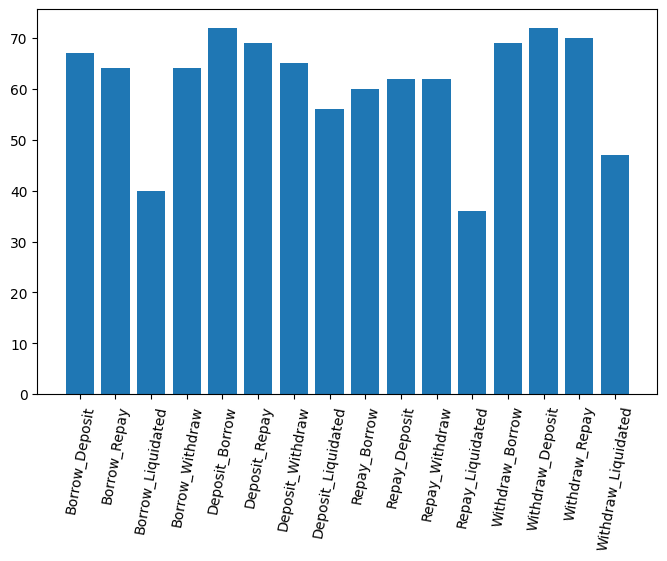

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(selected_features_str, lenght_col)
plt.xticks(rotation=80)   # rotate by 45 degrees
plt.show()